# iMD-XR with glucose-GluHUT structures


In [ ]:
# Load the xml files of the equilibrates structures

from nanover.omni import OmniRunner
from nanover.openmm import OpenMMSimulation
from nanover.app import RenderingSelection
from nanover.websocket.record import record_from_runner

sim1 = OpenMMSimulation.from_xml_path('../xml_files/glucose/glucose_geomtries0.xml')
sim1.include_forces = True
sim1.include_velocities =False
sim1.frame_interval = 5

sim2 = OpenMMSimulation.from_xml_path('../xml_files/glucose/glucose_geomtries1.xml')
sim2.include_forces = True
sim2.include_velocities =False
sim2.frame_interval = 5

sim3 = OpenMMSimulation.from_xml_path('../xml_files/glucose/glucose_geomtries2.xml')
sim3.include_forces = True
sim3.include_velocities =False
sim3.frame_interval = 5

sim4 = OpenMMSimulation.from_xml_path('../xml_files/glucose/glucose_geomtries3.xml')
sim4.include_forces = True
sim4.include_velocities =False
sim4.frame_interval = 5

sim5 = OpenMMSimulation.from_xml_path('../xml_files/glucose/glucose_geomtries4.xml')
sim5.include_forces = True
sim5.include_velocities =False
sim5.frame_interval = 5

## Choose render

In [ ]:
# Defining selections and rendering for gluhut 
gluhut_selection = RenderingSelection("selection.gluhut")
gluhut_selection.set_particles(list(range(0, 58)) + list(range(59,159)))
gluhut_selection.renderer  = {
            'color': 'cpk',
            'scale': 0.08,
            'render': 'liquorice'
        }
# Defining selections and rendering for sugars 
sugar_selection = RenderingSelection("selection.sugar")
sugar_selection.set_particles(list(range(160, 184)))
sugar_selection.renderer = {
    'color': {
        'type': 'cpk',   
        'scheme': 'nanover'
    },
    'scale': 0.04,     
    'render': 'liquorice'
}

# Selections for hide the solvent in the simulations
hide_water_1 = RenderingSelection("selection.water1")
hide_water_1.set_particles(list(range(183, 23070)))
hide_water_1.hide = True
hide_water_1.interaction_method = "none"

## Set the runner and client

In [ ]:

try:
    imd_runner.close()
except:
    pass
    
imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)

imd_runner.set_simulation_selections(sim1, hide_water_1)
imd_runner.set_simulation_selections(sim2, hide_water_1)
imd_runner.set_simulation_selections(sim3, hide_water_1)
imd_runner.set_simulation_selections(sim4, hide_water_1)
imd_runner.set_simulation_selections(sim5, hide_water_1)




# Start the runner


imd_runner.load(0)
imd_runner.play()


In [ ]:
from nanover.websocket import NanoverImdClient

try:
    client.close()
except:
    pass

# Start a Nanover client, using autoconnect to find the server we started earlier
client = NanoverImdClient.from_runner(imd_runner)


# Wait for the first frame to be recieved about the current state of the system
client.wait_until_first_frame(check_interval=0.5, timeout=10)
first_frame = client.current_frame
print("Client connected, recieved frame with {0} atom(s)".format(first_frame.particle_count))

# Set the interaction force's scale and type
client.set_shared_value("suggested.interaction.scale", 1000)
client.set_shared_value("suggested.interaction.type", "spring")

In [ ]:
# Record the simulation


path = 'gluhut_glucose_recording.nanover.zip' # choose a file name for the recording
record_from_runner(imd_runner, path)

Now in the NanoVer VR client you can run your session. <br>
The video below shows how we recored our trajectories of unbiding the sugar from the receptor. <br>
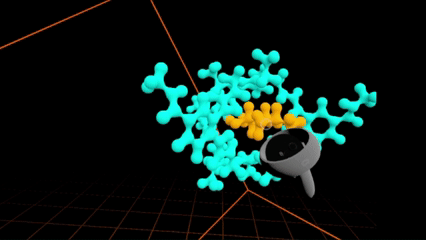 <br>
To apply force to the COM of the sugar, enable the *residue* mode in the NanoVer menu. <br>
In one session, you can play with the other structure you have loaded at the beginning. Run the next command if you want to change the structure.

In [ ]:
imd_runner.load(0) # chose the structure by the index, 0 to 4

In [ ]:
# Close the server once you've finished your session.
imd_runner.close()

## Extract interaction points from the recording and run multiple simulations <br>
To gather more data on the pathway you've just recorded, we need to get your interactions point and repeat the iMD-XR simulation. <br>


In [ ]:
import numpy as np
import pandas as pd
import MDAnalysis as mda
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from nanover.mdanalysis import universes_from_recording, universe_from_recording

In [ ]:
# Obtain the interaction points csv file

trajectories = glob.glob(os.path.join('.', 'gluhut_glucose_recording.nanover.zip'))


# Create empty lists to append simulation data to
frames = []                        # Frame indices
simulation_times = []              # Time elapsed in simulation time
timestamps = []                    # Timestamps for synchronising trajectory and state data

for x in trajectories:
    print(x)
    u = universe_from_recording(x)
    frames_i = []                        # Frame indices
    simulation_times_i = []              # Time elapsed in simulation time
    timestamps_i = []                    # Timestamps for synchronising trajectory and state data



  
    # Iterate through simulation frames and retrieve simulation data, skipping the first frame
    for timestep in u.trajectory:
        if timestep.frame != 0:
            frames_i.append(timestep.frame)
            simulation_times_i.append(timestep.time)
            timestamps_i.append(int(timestep.data["elapsed"]))
  

    frames.append(frames_i)
    simulation_times.append(simulation_times_i)
    timestamps.append(timestamps_i)


from nanover.recording.reading import NanoverRecordingReader, iter_full_view
# Extract interaction's particles
# interaction positions, timestamps to synch the frame and state data
timestamps_state = []
position_int = []
i =0 
for x in trajectories:

        print(x)
        last_path = None
        position_i = []
        timestamps_state_i = []

        for time, frame, state in iter_full_view(x):
                if time in timestamps[i]:
                            if frame is not None and state is not None:
                                timestamps_state_i.append(time)
                                interaction_updated = [key for key in state if key.startswith("interaction")]
                               # print(state[interaction_updated[0]])
                                if interaction_updated:
                                       position_i.append(np.array(state[interaction_updated[0]]['position'])) # in nanometers

                                else:
                                       pass

        position_i = np.array(position_i)
        position_int.append(position_i)
        timestamps_state.append(timestamps_state_i)
        i += 1
# extract the interaction points and save them in a csv file
for i in range(len(trajectories)):   
    x = []
    y = []
    z = []
    for t in range(0, len(position_int[i])):
        x.append(position_int[i][t][0])
        y.append(position_int[i][t][1])
        z.append(position_int[i][t][2])


    df = pd.DataFrame({
                "x" : x,
                "y" : y,
                "z" : z
            })
    filename = '{}_interaction_points.csv'.format(trajectories[i])
    df.to_csv(filename, index=False)



To repeat the simulation, start a new server and set the interaction through a client.

In [ ]:
# start a new server

try:
    imd_runner.close()
except:
    pass
    
imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)

imd_runner.set_simulation_selections(sim1, hide_water_1)
imd_runner.set_simulation_selections(sim2, hide_water_1)
imd_runner.set_simulation_selections(sim3, hide_water_1)
imd_runner.set_simulation_selections(sim4, hide_water_1)
imd_runner.set_simulation_selections(sim5, hide_water_1)


In [ ]:
#load the interaction points
interaction_point = pd.read_csv("gluhut_glucose_recording.nanover.zip_interaction_points.csv")

If you were interacting with the COM of the sugar, set the particles indeces.

In [ ]:
from nanover.imd.particle_interaction import ParticleInteraction

cm_particles = [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182]

In [ ]:
import time 
for i in range(0, 5): #change 5 to the number of simulation you want to record
    print("Repetition : ", i)
    #start the simulation 
    imd_runner.load(0) # change 0,  to the structure you want to load
    imd_runner.pause()

    try:
        client.close()
    except:
        pass

    # Start a Nanover client, using autoconnect to find the server we started earlier
    client = NanoverImdClient.from_runner(imd_runner)


    # Wait for the first frame to be recieved about the current state of the system
    client.wait_until_first_frame(check_interval=0.5, timeout=10)
    first_frame = client.current_frame

    anchor1_id = client.start_interaction()

    
    print("Running the simulation")
    for i in range(len(interaction_point["x"])):

        position = np.array((interaction_point["x"][i], interaction_point["y"][i], interaction_point["z"][i]))
        anchor1 = ParticleInteraction(position=position, scale=1000, particles=cm_particles, interaction_type='spring')
        client.update_interaction(anchor1_id, anchor1)
        imd_runner.step()
        time.sleep(1/30)

If you want to apply our pathways, this is how we have proceeded.

In [ ]:

file_list_0 = [f for f in glob.glob(os.path.join('.', '../pathways/glucose/geom_frame_interval5*_interaction_points.csv')) if 'strc_0' in f]
file_list_1 = [f for f in glob.glob(os.path.join('.', '../pathways/glucose/geom_frame_interval5*_interaction_points.csv')) if 'strc_1' in f]
file_list_2 = [f for f in glob.glob(os.path.join('.', '../pathways/glucose//geom_frame_interval5*_interaction_points.csv')) if 'strc_2' in f] 
file_list_3 = [f for f in glob.glob(os.path.join('.', '../pathways/glucose//geom_frame_interval5*_interaction_points.csv')) if 'strc_3' in f]
file_list_4 = [f for f in glob.glob(os.path.join('.', '../pathways/glucose//geom_frame_interval5*_interaction_points.csv')) if 'strc_4' in f]


In [ ]:
from nanover.websocket import NanoverImdClient
from nanover.imd.particle_interaction import ParticleInteraction
import numpy as np
import pandas as pd

for file in file_list_0:    
    try:
        imd_runner.close()
    except:
        pass
    print("FILE : ", file)
    imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)
    #imd_runner = OmniRunner.with_basic_server(sim1, name="Gluhut-server")


    #imd_runner.set_simulation_selections(sim, gluhut_selection, sugar_selection, hide_water_1)
    imd_runner.set_simulation_selections(sim1, hide_water_1)
    imd_runner.set_simulation_selections(sim2, hide_water_1)
    imd_runner.set_simulation_selections(sim3, hide_water_1)
    imd_runner.set_simulation_selections(sim4, hide_water_1)
    imd_runner.set_simulation_selections(sim5, hide_water_1)

    imd_runner.load(0)
    imd_runner.pause()
    print(" RUNNER STARTS ")
    path = '{}_multiples.nanover.zip'.format(file)
    record_from_runner(imd_runner, path)

    interaction_point = pd.read_csv(file)
    cm_particles = [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182]

    for i in range(0, 5):
            print("Repetition : ", i)
            imd_runner.load(0)
            imd_runner.pause()

            try:
                client.close()
            except:
                pass

            # Start a Nanover client, using autoconnect to find the server we started earlier
            client = NanoverImdClient.from_runner(imd_runner)


            # Wait for the first frame to be recieved about the current state of the system
            client.wait_until_first_frame(check_interval=0.5, timeout=10)
            first_frame = client.current_frame

            anchor1_id = client.start_interaction()

            import time
            print("calculating..")
            for i in range(len(interaction_point["x"])):

                position = np.array((interaction_point["x"][i], interaction_point["y"][i], interaction_point["z"][i]))
                anchor1 = ParticleInteraction(position=position, scale=1000, particles=cm_particles, interaction_type='spring')
                client.update_interaction(anchor1_id, anchor1)
                imd_runner.step()
                time.sleep(1/30)

imd_runner.close()

In [ ]:
for file in file_list_1:    
    try:
        imd_runner.close()
    except:
        pass
    print("FILE : ", file)
    imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)


    #imd_runner.set_simulation_selections(sim, gluhut_selection, sugar_selection, hide_water_1)
    imd_runner.set_simulation_selections(sim1, hide_water_1)
    imd_runner.set_simulation_selections(sim2, hide_water_1)
    imd_runner.set_simulation_selections(sim3, hide_water_1)
    imd_runner.set_simulation_selections(sim4, hide_water_1)
    imd_runner.set_simulation_selections(sim5, hide_water_1)

    imd_runner.load(1)
    imd_runner.pause()
    print(" RUNNER STARTS ")
    path = '{}_multiples.nanover.zip'.format(file)
    record_from_runner(imd_runner, path)

    interaction_point = pd.read_csv(file)
    cm_particles = [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182]

    for i in range(0, 5):
            print("Repetition : ", i)
            imd_runner.load(1)
            imd_runner.pause()

            try:
                client.close()
            except:
                pass

            # Start a Nanover client, using autoconnect to find the server we started earlier
            client = NanoverImdClient.from_runner(imd_runner)


            # Wait for the first frame to be recieved about the current state of the system
            client.wait_until_first_frame(check_interval=0.5, timeout=10)
            first_frame = client.current_frame

            anchor1_id = client.start_interaction()

            import time
            print("calculating..")
            for i in range(len(interaction_point["x"])):

                position = np.array((interaction_point["x"][i], interaction_point["y"][i], interaction_point["z"][i]))
                anchor1 = ParticleInteraction(position=position, scale=1000, particles=cm_particles, interaction_type='spring')
                client.update_interaction(anchor1_id, anchor1)
                imd_runner.step()
                time.sleep(1/30)

imd_runner.close()


In [ ]:

for file in file_list_2:    
    try:
        imd_runner.close()
    except:
        pass
    print("FILE : ", file)
    imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)


    imd_runner.set_simulation_selections(sim1, hide_water_1)
    imd_runner.set_simulation_selections(sim2, hide_water_1)
    imd_runner.set_simulation_selections(sim3, hide_water_1)
    imd_runner.set_simulation_selections(sim4, hide_water_1)
    imd_runner.set_simulation_selections(sim5, hide_water_1)

    imd_runner.load(2)
    imd_runner.pause()
    print(" RUNNER STARTS ")
    path = '{}_multiples.nanover.zip'.format(file)
    record_from_runner(imd_runner, path)

    interaction_point = pd.read_csv(file)
    cm_particles = [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182]

    for i in range(0, 5):
            print("Repetition : ", i)
            imd_runner.load(2)
            imd_runner.pause()

            try:
                client.close()
            except:
                pass

            # Start a Nanover client, using autoconnect to find the server we started earlier
            client = NanoverImdClient.from_runner(imd_runner)


            # Wait for the first frame to be recieved about the current state of the system
            client.wait_until_first_frame(check_interval=0.5, timeout=10)
            first_frame = client.current_frame

            anchor1_id = client.start_interaction()

            import time
            print("calculating..")
            for i in range(len(interaction_point["x"])):

                position = np.array((interaction_point["x"][i], interaction_point["y"][i], interaction_point["z"][i]))
                anchor1 = ParticleInteraction(position=position, scale=1000, particles=cm_particles, interaction_type='spring')
                client.update_interaction(anchor1_id, anchor1)
                imd_runner.step()
                time.sleep(1/30)

imd_runner.close()

In [ ]:

for file in file_list_3:    
    try:
        imd_runner.close()
    except:
        pass
    print("FILE : ", file)
    imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)
  
    imd_runner.set_simulation_selections(sim1, hide_water_1)
    imd_runner.set_simulation_selections(sim2, hide_water_1)
    imd_runner.set_simulation_selections(sim3, hide_water_1)
    imd_runner.set_simulation_selections(sim4, hide_water_1)
    imd_runner.set_simulation_selections(sim5, hide_water_1)

    imd_runner.load(3)
    imd_runner.pause()
    print(" RUNNER STARTS ")
    path = '{}_multiples.nanover.zip'.format(file)
    record_from_runner(imd_runner, path)

    interaction_point = pd.read_csv(file)
    cm_particles = [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182]

    for i in range(0, 5):
            print("Repetition : ", i)
            imd_runner.load(3)
            imd_runner.pause()

            try:
                client.close()
            except:
                pass

            # Start a Nanover client, using autoconnect to find the server we started earlier
            client = NanoverImdClient.from_runner(imd_runner)


            # Wait for the first frame to be recieved about the current state of the system
            client.wait_until_first_frame(check_interval=0.5, timeout=10)
            first_frame = client.current_frame

            anchor1_id = client.start_interaction()

            import time
            print("calculating..")
            for i in range(len(interaction_point["x"])):

                position = np.array((interaction_point["x"][i], interaction_point["y"][i], interaction_point["z"][i]))
                anchor1 = ParticleInteraction(position=position, scale=1000, particles=cm_particles, interaction_type='spring')
                client.update_interaction(anchor1_id, anchor1)
                imd_runner.step()
                time.sleep(1/30)

imd_runner.close()

In [ ]:

for file in file_list_4:    
    try:
        imd_runner.close()
    except:
        pass
    print("FILE : ", file)
    imd_runner = OmniRunner.with_basic_server(sim1, sim2, sim3, sim4, sim5, name="Gluhut-server", port=0)

    imd_runner.set_simulation_selections(sim1, hide_water_1)
    imd_runner.set_simulation_selections(sim2, hide_water_1)
    imd_runner.set_simulation_selections(sim3, hide_water_1)
    imd_runner.set_simulation_selections(sim4, hide_water_1)
    imd_runner.set_simulation_selections(sim5, hide_water_1)

    imd_runner.load(4)
    imd_runner.pause()
    print(" RUNNER STARTS ")
    path = '{}_multiples.nanover.zip'.format(file)
    record_from_runner(imd_runner, path)

    interaction_point = pd.read_csv(file)
    cm_particles = [159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182]

    for i in range(0, 5):
            print("Repetition : ", i)
            imd_runner.load(2)
            imd_runner.pause()

            try:
                client.close()
            except:
                pass

            # Start a Nanover client, using autoconnect to find the server we started earlier
            client = NanoverImdClient.from_runner(imd_runner)


            # Wait for the first frame to be recieved about the current state of the system
            client.wait_until_first_frame(check_interval=0.5, timeout=10)
            first_frame = client.current_frame

            anchor1_id = client.start_interaction()

            import time
            print("calculating..")
            for i in range(len(interaction_point["x"])):

                position = np.array((interaction_point["x"][i], interaction_point["y"][i], interaction_point["z"][i]))
                anchor1 = ParticleInteraction(position=position, scale=1000, particles=cm_particles, interaction_type='spring')
                client.update_interaction(anchor1_id, anchor1)
                imd_runner.step()
                time.sleep(1/30)

imd_runner.close()